In [1]:
import os 
cwd = os.getcwd()
cwd

os.chdir("/Users/jmthomas565/Desktop/Education/Applied Stats MSc/MSc Project/Git Files/msc-project-source-code-files-24-25-jmthomas565/Code/Project Code Pipeline")

new_cwd = os.getcwd() 

new_cwd


'/Users/jmthomas565/Desktop/Education/Applied Stats MSc/MSc Project/Git Files/msc-project-source-code-files-24-25-jmthomas565/Code/Project Code Pipeline'

In [2]:
%run 00_inititial_transformations.ipynb

['2017-07-01', '2017-07-02', '2017-07-03', '2017-07-04', '2017-07-05'] ... ['2022-09-27', '2022-09-28', '2022-09-29', '2022-09-30', '2022-10-01']


### PACF

In [4]:
bike_sales_data.head()

,sales,branded_search_spend,nonbranded_search_spend,facebook_spend,print_spend,ooh_spend,tv_spend,radio_spend,gdp,base_rate,UNRATENSA_daily
Week,,,,,,,,,,,
2017-07-23,58850.0,1528.8,463.32,802.620,0,0,0,0,4958224,1.15,4.6
2017-07-30,62050.0,1575.6,468.00,819.312,0,0,0,0,4958224,1.15,4.6
2017-08-06,59388.0,1544.4,477.36,749.034,0,0,0,0,4958224,1.16,4.5
2017-08-13,56964.0,1528.8,468.00,741.468,0,0,0,0,4958224,1.16,4.5
2017-08-20,53460.0,1560.0,458.64,811.200,0,0,0,0,4958224,1.16,4.5


In [5]:
bike_sales_data_stationary = bike_sales_data.copy()

bike_sales_data_stationary['sales'] = bike_sales_data_stationary['sales'].diff()

bike_sales_data_stationary.dropna(inplace=True)

In [6]:
bike_sales_data.head()

,sales,branded_search_spend,nonbranded_search_spend,facebook_spend,print_spend,ooh_spend,tv_spend,radio_spend,gdp,base_rate,UNRATENSA_daily
Week,,,,,,,,,,,
2017-07-23,58850.0,1528.8,463.32,802.620,0,0,0,0,4958224,1.15,4.6
2017-07-30,62050.0,1575.6,468.00,819.312,0,0,0,0,4958224,1.15,4.6
2017-08-06,59388.0,1544.4,477.36,749.034,0,0,0,0,4958224,1.16,4.5
2017-08-13,56964.0,1528.8,468.00,741.468,0,0,0,0,4958224,1.16,4.5
2017-08-20,53460.0,1560.0,458.64,811.200,0,0,0,0,4958224,1.16,4.5


Text(0, 0.5, 'Partial Autocorrelation')

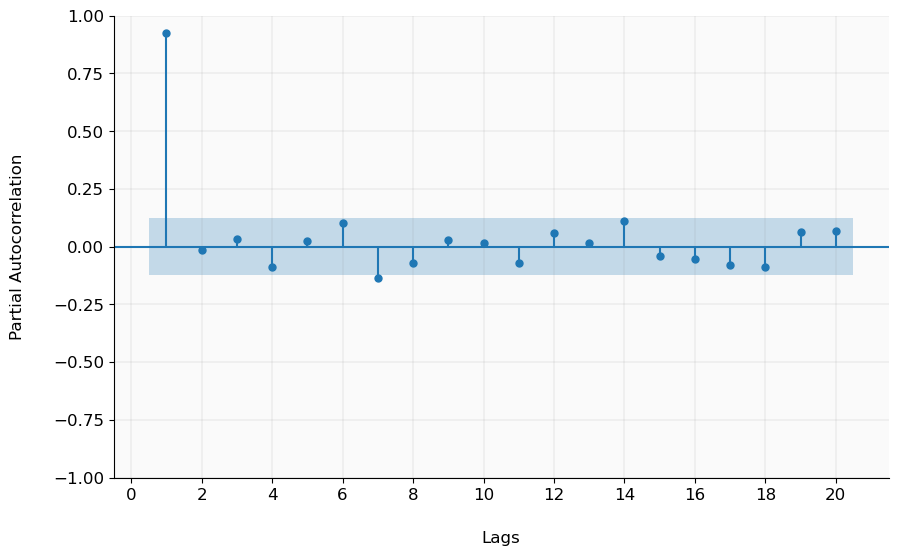

In [7]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize = (10, 6))


plot_pacf(bike_sales_data['sales'], title = '', lags=20, method='ywm', zero=False, ax = ax)  # lags=12 months


plt.rcParams['font.family'] = 'Times New Roman'

ax.xaxis.set_tick_params(labelsize=10)


ax.yaxis.set_tick_params(labelsize=10)


ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)



ax.tick_params(axis='both', which='major', labelsize=12, width=0.8)
ax.tick_params(axis='both', which='minor', labelsize=10, width=0.5)

ax.set_xticks(np.arange(0, 21, 2))

ax.xaxis.labelpad=20

ax.yaxis.labelpad=20

ax.set_facecolor('#fafafa')


ax.grid (color='grey', linestyle='-', linewidth=0.25, alpha=0.5)

ax.set_xlabel('Lags', fontsize = 12)
ax.set_ylabel('Partial Autocorrelation', fontsize = 12)





Text(0, 0.5, 'Partial Autocorrelation')

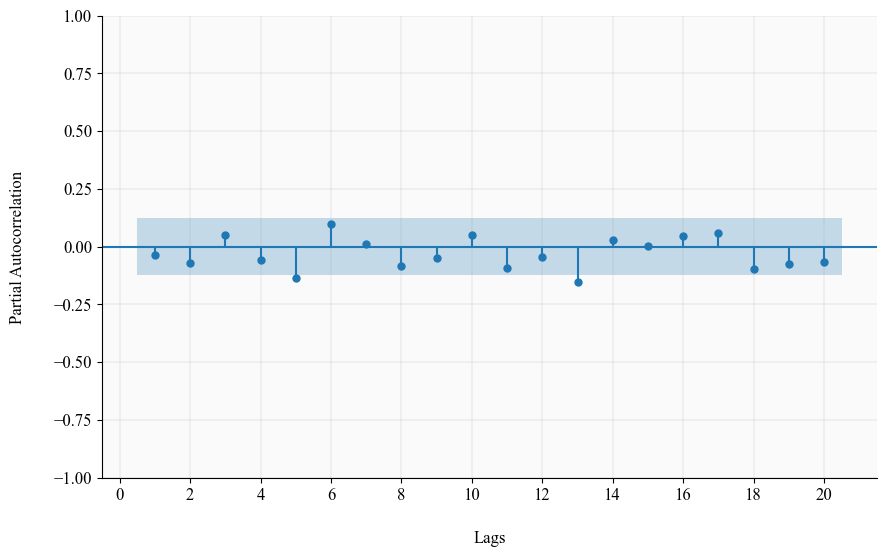

In [8]:

fig, ax = plt.subplots(figsize = (10, 6))


plot_pacf(bike_sales_data_stationary['sales'], title = '', lags=20, method='ywm', zero=False, ax = ax)  # lags=12 months


plt.rcParams['font.family'] = 'Times New Roman'

ax.xaxis.set_tick_params(labelsize=10)


ax.yaxis.set_tick_params(labelsize=10)


ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)



ax.tick_params(axis='both', which='major', labelsize=12, width=0.8)
ax.tick_params(axis='both', which='minor', labelsize=10, width=0.5)

ax.set_xticks(np.arange(0, 21, 2))

ax.xaxis.labelpad=20

ax.yaxis.labelpad=20

ax.set_facecolor('#fafafa')


ax.grid (color='grey', linestyle='-', linewidth=0.25, alpha=0.5)

ax.set_xlabel('Lags', fontsize = 12)
ax.set_ylabel('Partial Autocorrelation', fontsize = 12)





### AIC

In [10]:
X_train.head()

,branded_search_spend,nonbranded_search_spend,facebook_spend,print_spend,ooh_spend,tv_spend,radio_spend,gdp,base_rate,UNRATENSA_daily
Week,,,,,,,,,,
2017-07-23,1528.8,463.32,802.620,0,0,0,0,4958224,1.15,4.6
2017-07-30,1575.6,468.00,819.312,0,0,0,0,4958224,1.15,4.6
2017-08-06,1544.4,477.36,749.034,0,0,0,0,4958224,1.16,4.5
2017-08-13,1528.8,468.00,741.468,0,0,0,0,4958224,1.16,4.5
2017-08-20,1560.0,458.64,811.200,0,0,0,0,4958224,1.16,4.5


In [11]:
#Calculating and printing AIC calcualtions

import pandas as pd
from statsmodels.tsa.api import VAR

#creating the VAR model to compare lags
model = VAR(X_train)

lag_order = model.select_order(maxlags=10)

print("-" * 45)
for criterion, lags in lag_order.selected_orders.items():
    print(f"{criterion.upper()}: {lags} lags")

print(lag_order.summary())

recommended_lags = lag_order.selected_orders['aic'] 
print(f"\nRecommended number of lags for ARDL: {recommended_lags}")

---------------------------------------------
AIC: 1 lags
BIC: 1 lags
HQIC: 1 lags
FPE: 1 lags
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        104.5       104.7   2.472e+45       104.6
1       86.94*      88.77*  5.751e+37*      87.68*
2        87.36       90.85   8.786e+37       88.77
3        87.90       93.04   1.526e+38       89.98
4        88.33       95.13   2.431e+38       91.08
5        88.69       97.16   3.692e+38       92.11
6        87.98       98.11   1.999e+38       92.08
7        88.07       99.87   2.485e+38       92.85
8        88.30       101.8   3.713e+38       93.75
9        87.69       102.8   2.555e+38       93.81
10       87.70       104.5   3.532e+38       94.49
--------------------------------------------------

Recommended number of lags for ARDL: 1


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
